# 04 - Modelo Baseline: Regressão Logística

Baseline simples e interpretável para prever `acidente_grave_ou_fatal` (óbito ou ferido grave) a partir de condições da via, clima, horário, tipo de veículo e traçado da estrada.

**Correção aplicada nesta versão:** o campo `tracado_via` é multi-rótulo (ex: `"Reta;Declive"`) e a ordem dos tokens varia entre registros do mesmo tipo de trecho (`"Reta;Declive"` x `"Declive;Reta"` eram tratados como categorias diferentes no one-hot encoding, fragmentando ~680 colunas). A preparação de dados (`src/preparar_dados.py`) agora decompõe esse campo em flags binárias (`tracado_declive`, `tracado_aclive`, etc.), reduzindo a dimensionalidade e preservando o sinal do relevo da via.

## 1. Importações

In [1]:
import sys
sys.path.append('../src')

import time
import json
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score
)

from preparar_dados import carregar_dados

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


## 2. Carregamento e Preparação dos Dados

Toda a engenharia de atributos (turno, decomposição do traçado, one-hot encoding e padronização) está centralizada em `src/preparar_dados.py` e é reutilizada pelos 4 notebooks de modelo, garantindo que todos comparem exatamente a mesma base.

In [2]:
X_train, X_test, y_train, y_test = carregar_dados()

print(f"Registros de treino: {X_train.shape[0]} | Registros de teste: {X_test.shape[0]}")
print(f"Total de features após encoding: {X_train.shape[1]}")


Registros de treino: 151713 | Registros de teste: 65021
Total de features após encoding: 77


## 3. Treinamento do Modelo Baseline

`class_weight='balanced'` compensa o desbalanceamento entre acidentes leves e graves/fatais sem descartar dados.

In [3]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

tempo_inicio = time.time()
modelo.fit(X_train, y_train)
tempo_treino = time.time() - tempo_inicio

print(f"✅ Modelo Baseline treinado em {tempo_treino:.3f} segundos!")


✅ Modelo Baseline treinado em 1.820 segundos!


## 4. Avaliação do Modelo

--- RELATÓRIO DE CLASSIFICAÇÃO: Regressão Logística ---
                     precision    recall  f1-score   support

0: Leve/Sem Vítimas       0.95      0.70      0.80     56583
     1: Grave/Fatal       0.27      0.75      0.40      8438

           accuracy                           0.70     65021
          macro avg       0.61      0.72      0.60     65021
       weighted avg       0.86      0.70      0.75     65021



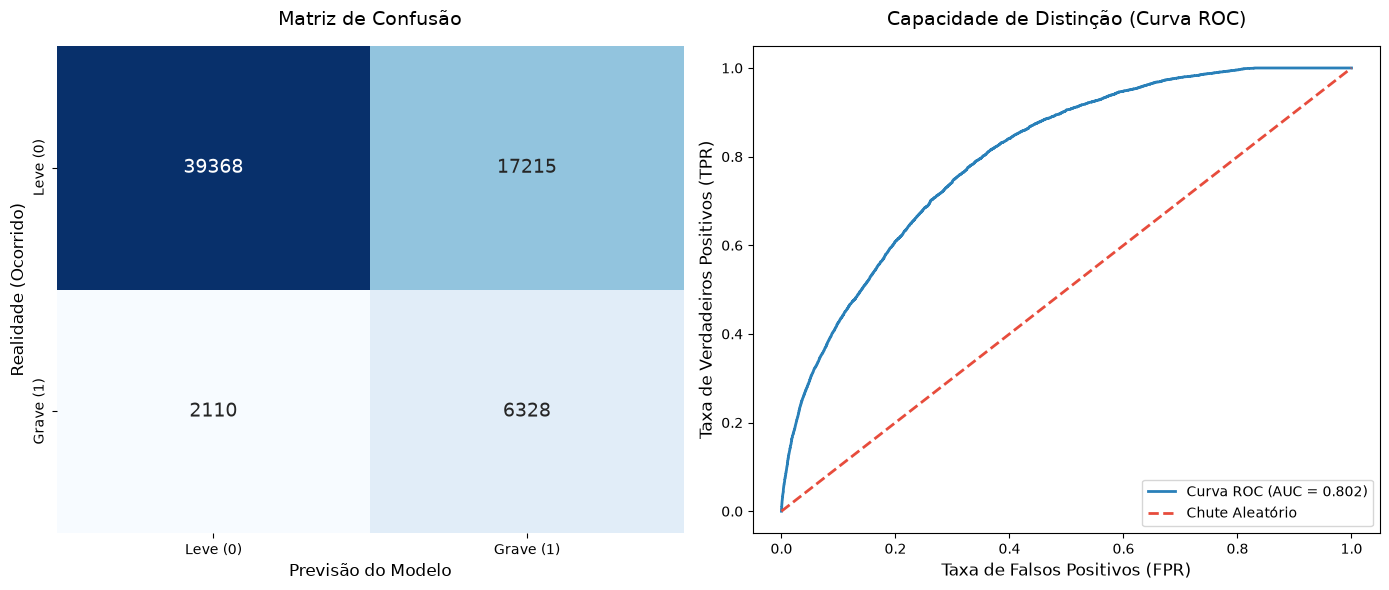

Acurácia: 0.7028 | Precision: 0.2688 | Recall: 0.7499 | AUC: 0.8020


In [4]:
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("--- RELATÓRIO DE CLASSIFICAÇÃO: Regressão Logística ---")
print(classification_report(y_test, y_pred, target_names=['0: Leve/Sem Vítimas', '1: Grave/Fatal']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Leve (0)', 'Grave (1)'],
            yticklabels=['Leve (0)', 'Grave (1)'],
            cbar=False, annot_kws={"size": 14})
axes[0].set_title('Matriz de Confusão', fontsize=14, pad=15)
axes[0].set_xlabel('Previsão do Modelo', fontsize=12)
axes[0].set_ylabel('Realidade (Ocorrido)', fontsize=12)

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#2980b9', lw=2, label=f'Curva ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='#e74c3c', lw=2, linestyle='--', label='Chute Aleatório')
axes[1].set_title('Capacidade de Distinção (Curva ROC)', fontsize=14, pad=15)
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"Acurácia: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | AUC: {auc:.4f}")


## 5. Interpretação do Modelo: Peso das Variáveis (Odds Ratio)

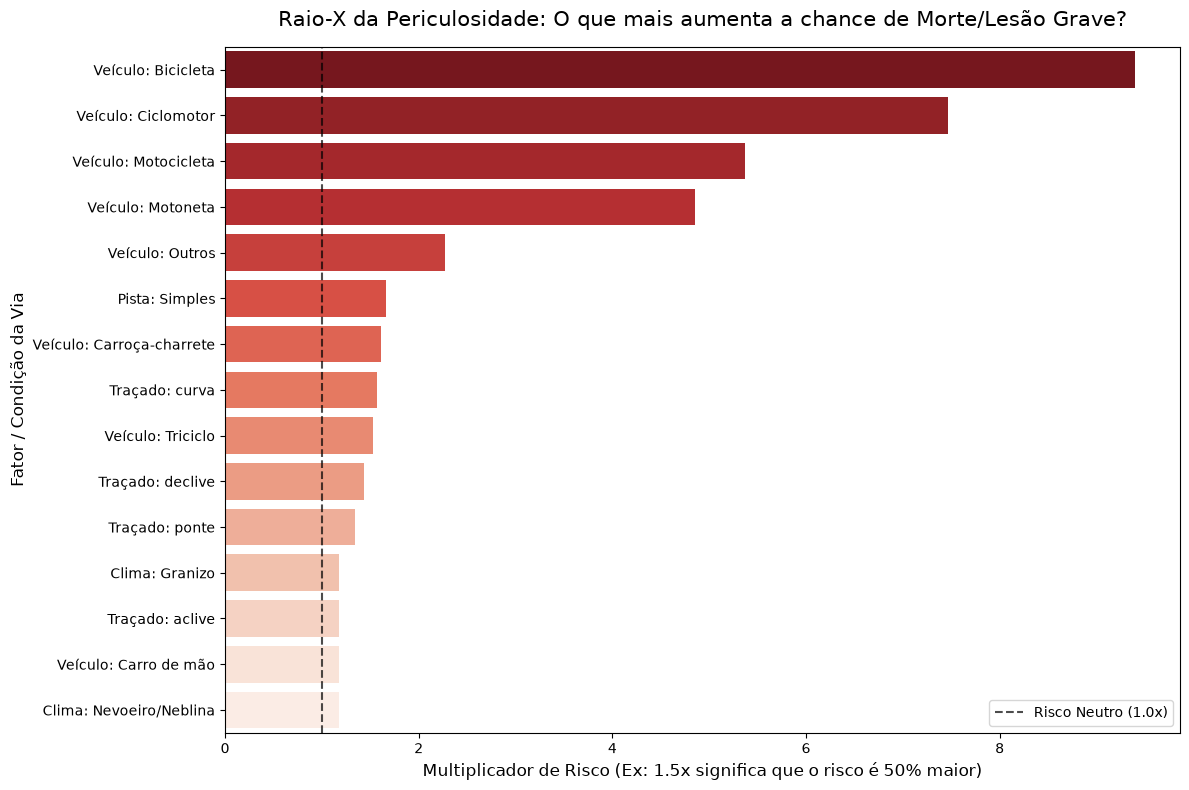

--- TOP 10 FATORES QUE MAIS AUMENTAM A PERICULOSIDADE ---
           Variavel_Limpa  Multiplicador_Risco
       Veículo: Bicicleta             9.392486
      Veículo: Ciclomotor             7.464824
     Veículo: Motocicleta             5.370123
        Veículo: Motoneta             4.854597
          Veículo: Outros             2.269182
           Pista: Simples             1.657626
Veículo: Carroça-charrete             1.608755
           Traçado: curva             1.564317
        Veículo: Triciclo             1.529826
         Traçado: declive             1.429974


In [5]:
coeficientes = modelo.coef_[0]
odds_ratios = np.exp(coeficientes)

df_importancia = pd.DataFrame({
    'Variavel': X_train.columns,
    'Coeficiente': coeficientes,
    'Multiplicador_Risco': odds_ratios
})

df_importancia = df_importancia[~df_importancia['Variavel'].str.contains('Não Informado|NaN', case=False, na=False)]

substituicoes_prefixos = {
    'tipo_veiculo_': 'Veículo: ',
    'tracado_': 'Traçado: ',
    'condicao_metereologica_': 'Clima: ',
    'fase_dia_': 'Luz: ',
    'turno_': 'Turno: ',
    'tipo_pista_': 'Pista: ',
    'sentido_via_': 'Sentido: ',
    'uso_solo_': 'Local: '
}

df_importancia['Variavel_Limpa'] = df_importancia['Variavel']
for prefixo, novo_nome in substituicoes_prefixos.items():
    df_importancia['Variavel_Limpa'] = df_importancia['Variavel_Limpa'].str.replace(prefixo, novo_nome)

df_importancia = df_importancia.sort_values(by='Multiplicador_Risco', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=df_importancia.head(15), x='Multiplicador_Risco', y='Variavel_Limpa', palette='Reds_r')
plt.axvline(x=1, color='black', linestyle='--', alpha=0.7, label='Risco Neutro (1.0x)')
plt.title('Raio-X da Periculosidade: O que mais aumenta a chance de Morte/Lesão Grave?', fontsize=15, pad=15)
plt.xlabel('Multiplicador de Risco (Ex: 1.5x significa que o risco é 50% maior)', fontsize=12)
plt.ylabel('Fator / Condição da Via', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print("--- TOP 10 FATORES QUE MAIS AUMENTAM A PERICULOSIDADE ---")
print(df_importancia.head(10)[['Variavel_Limpa', 'Multiplicador_Risco']].to_string(index=False))


## 6. Exportação do Modelo e das Métricas

In [6]:
os.makedirs('../models', exist_ok=True)

joblib.dump(modelo, '../models/modelo_regressao_logistica.pkl')
joblib.dump(X_train.columns.tolist(), '../models/colunas_treino.pkl')

resultado = {
    'chave': 'regressao_logistica',
    'algoritmo': 'Regressão Logística (Baseline)',
    'acuracia': round(float(acc), 4),
    'precision': round(float(prec), 4),
    'recall': round(float(rec), 4),
    'auc_score': round(float(auc), 4),
    'tempo_segundos': round(float(tempo_treino), 4),
}

with open('../models/resultados_regressao_logistica.json', 'w', encoding='utf-8') as f:
    json.dump(resultado, f, ensure_ascii=False, indent=2)

print(f"✅ Modelo e métricas de Regressão Logística (Baseline) exportados com sucesso!")
resultado


✅ Modelo e métricas de Regressão Logística (Baseline) exportados com sucesso!


{'chave': 'regressao_logistica',
 'algoritmo': 'Regressão Logística (Baseline)',
 'acuracia': 0.7028,
 'precision': 0.2688,
 'recall': 0.7499,
 'auc_score': 0.802,
 'tempo_segundos': 1.82}